##### Zadanie 1. Segmentacja obrazu za pomocą algorytmu k-średnich.
1.1. Wyświetlenie kodów RGB dla każdego piksela.

In [58]:
import cv2
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
image = cv2.imread('palm_tree.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 

In [60]:
print("Przykładowe kody RGB dla pierwszych 10 pikseli:")
print(image.reshape(-1, 3)[:10])

Przykładowe kody RGB dla pierwszych 10 pikseli:
[[ 28  35  63]
 [ 35  50  83]
 [ 98 118 153]
 [ 74  89 118]
 [ 23  28  47]
 [ 32  29  36]
 [ 22  16  20]
 [ 15   9  11]
 [ 31  31  43]
 [ 35  36  41]]


1.2. Wyświetlenie oryginalnego zdjęcia.

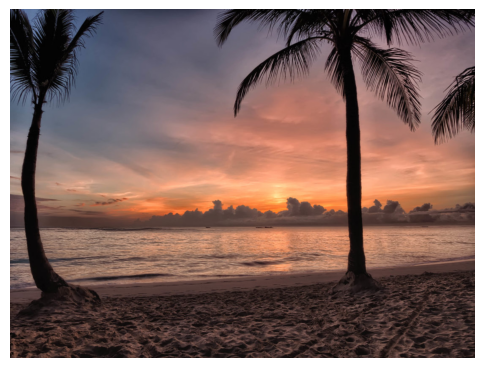

In [61]:
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

1.3. Wykonanie kwantyzacji kolorów za pomocą algorytmu k-średnich.

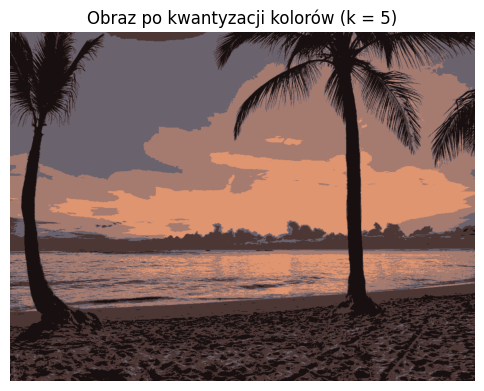

In [62]:
pixels = image.reshape((-1, 3))

# Ustawienie liczby klastrów (np. 5 klastrów)
k = 5
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(pixels)

# Zastąpienie pikseli kolorami centrów klastrów
segmented_pixels = kmeans.cluster_centers_[kmeans.labels_]
segmented_image = segmented_pixels.reshape(image.shape).astype(np.uint8)

# Wyświetlenie obrazu po kwantyzacji kolorów
plt.figure(figsize=(6, 6))
plt.title(f"Obraz po kwantyzacji kolorów (k = {k})")
plt.imshow(segmented_image)
plt.axis("off")
plt.show()

1.4. Wyświetlenie rozmiarów zdjęcia i liczbę kanałów kolorów (RGB). 

In [63]:
print("Rozmiar zdjęcia:", image.shape[:2])  # Wysokość i szerokość
print("Liczba kanałów kolorów (RGB):", image.shape[2])

Rozmiar zdjęcia: (825, 1100)
Liczba kanałów kolorów (RGB): 3


1.5. Przekształcenie danych z formatu 3D (w, h, c) do 2D (w * h, c).

In [64]:
pixels_2d = image.reshape(-1, 3)

# Wyświetlenie kształtu przed i po przekształceniu
print("Kształt obrazu 3D:", image.shape)     # (w, h, c)
print("Kształt obrazu 2D:", pixels_2d.shape)

Kształt obrazu 3D: (825, 1100, 3)
Kształt obrazu 2D: (907500, 3)


1.6. Zastosowanie algorytm k-średnich dla 6 klastrów.

In [65]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(pixels_2d)


KMeans(n_clusters=6, random_state=0)

1.7. Wyświetlenie etykiet klastrów dla każdego piksela.

In [66]:
print("Etykiety klastrów dla pierwszych 10 pikseli:")
print(kmeans.labels_[:10])

Etykiety klastrów dla pierwszych 10 pikseli:
[3 3 5 5 3 3 2 2 3 3]


1.8. Wyświetlenie współrzędne centroidów. 

In [67]:
print("Współrzędne centroidów (RGB):")
print(kmeans.cluster_centers_)

Współrzędne centroidów (RGB):
[[225.3442035  149.80133774 113.13886839]
 [ 90.73888512  66.89564784  64.21946204]
 [ 17.05307179  11.68495306  11.53865426]
 [ 55.6501672   39.30592305  38.17739171]
 [166.5614699  124.16975639 111.78680013]
 [107.21909895 101.38317482 114.483146  ]]


1.9. Zaokrąglenie współrzędnych centroidów (kolory) do 0 miejsc po przecinku. 

In [68]:
centroids_rounded = np.round(kmeans.cluster_centers_, 0).astype(int)
print("Zaokrąglone współrzędne centroidów (RGB):")
print(centroids_rounded)

Zaokrąglone współrzędne centroidów (RGB):
[[225 150 113]
 [ 91  67  64]
 [ 17  12  12]
 [ 56  39  38]
 [167 124 112]
 [107 101 114]]


1.10. Utworzenie skwantyzowanego obrazu, zamieniając każdy piksel na odpowiadający mu 
kolor centroidu. 

In [69]:
segmented_pixels = centroids_rounded[kmeans.labels_]
segmented_image = segmented_pixels.reshape(image.shape)

1.11. Wyświetlenie obrazu po kwantyzacji.

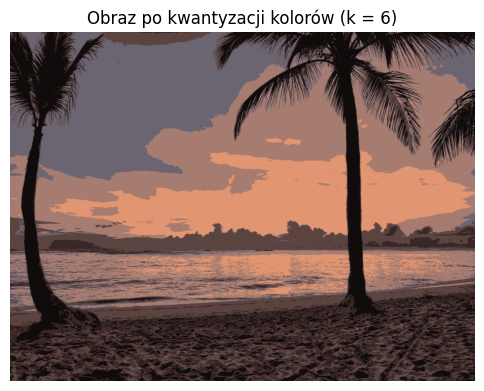

In [70]:
plt.figure(figsize=(6, 6))
plt.title(f"Obraz po kwantyzacji kolorów (k = {k})")
plt.imshow(segmented_image)
plt.axis("off")
plt.show()

### Zadanie 2. Korzystając ze zbioru danych iris.csv, proszę o wykonanie następujących czynności: 
2.1. Wczytanie danych. 
2.2. Sprawdzenie kompletności danych. 
2.3. Sprawdzenie statystyk podstawowych, informacji nt. danych.

In [71]:
df = pd.read_csv('iris.csv')
df.head()
print(df.describe())
print(df.isnull().sum())
print(df.dtypes)

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


2.4. Wykres punktowy zależności długości płatka w funkcji szerokości płatka. Na jaką ilość 
skupień można podzielić zbiór danych? 

C:\Users\DELL\AppData\Local\Temp\ipykernel_11124\996479068.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='petal_width', y='petal_length', palette='viridis')


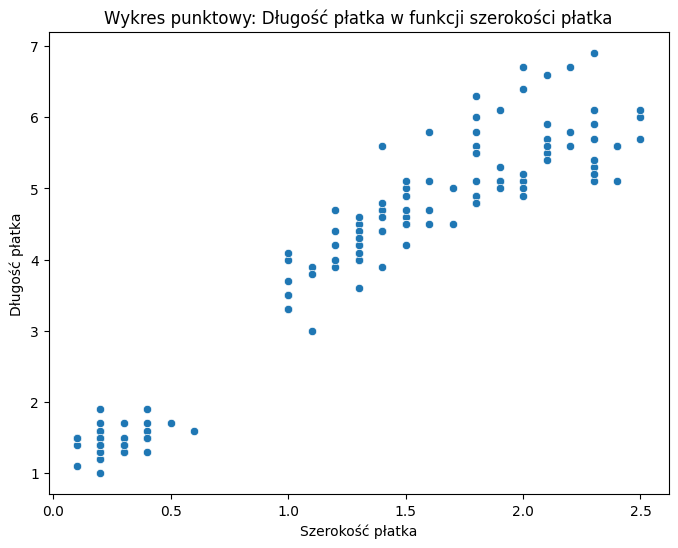

In [72]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal_width', y='petal_length', palette='viridis')
plt.title('Wykres punktowy: Długość płatka w funkcji szerokości płatka')
plt.xlabel('Szerokość płatka')
plt.ylabel('Długość płatka')
plt.show()

# na 3 skupienia ?

2.5.  Wykres  punktowy  zależności  długości  płatka  w  funkcji  szerokości  płatka,  dane 
różnicowane za pomocą gatunku/rodzaju.

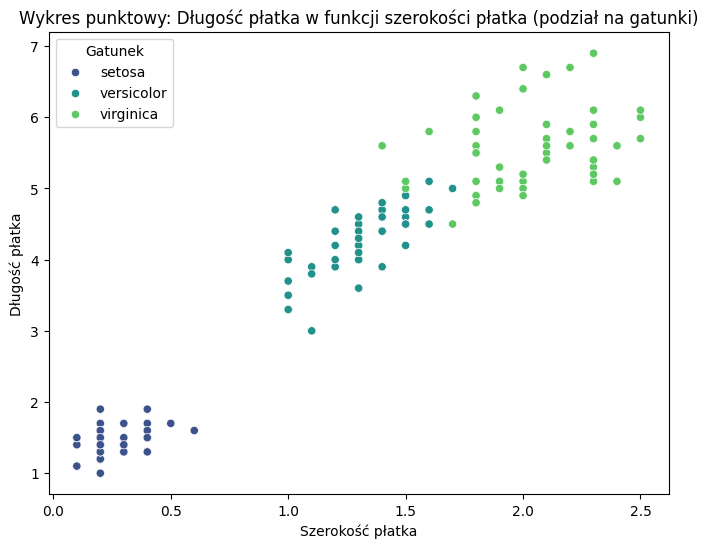

In [73]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal_width', y='petal_length', hue='species', palette='viridis')
plt.title('Wykres punktowy: Długość płatka w funkcji szerokości płatka (podział na gatunki)')
plt.xlabel('Szerokość płatka')
plt.ylabel('Długość płatka')
plt.legend(title='Gatunek')
plt.show()

2.6. Przygotowanie nowego obiektu df_iris, w której zostanie usunięta kolumna 'species'. 

In [74]:
df_iris = df.drop(columns=['species'])

2.7.  Przygotowanie  nowego  obiekt  df_iris_std  (z  punktu  2.6),  gdzie  dane  wejściowe  będą 
zestandaryzowane. 

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_iris_std = pd.DataFrame(scaler.fit_transform(df_iris), columns=df_iris.columns)

2.8. Przygotowanie nowego obiekt df_iris_norm (z punktu 2.6), gdzie dane wejściowe będą 
znormalizowane w zakresie [0,1].

In [76]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_iris_norm = pd.DataFrame(scaler.fit_transform(df_iris), columns=df_iris.columns)

2.9.  Przygotowanie  3  heatmap.  Jakich  informacji  nt.  zbioru  danych  dotyczących  irysów dostarczają mapy korelacji: 
##### a. dane wejściowe (punkt 2.6), 
##### b. dane zestandaryzowane (punkt 2.7), 
##### c. dane znormalizowane (punkt 2.8).

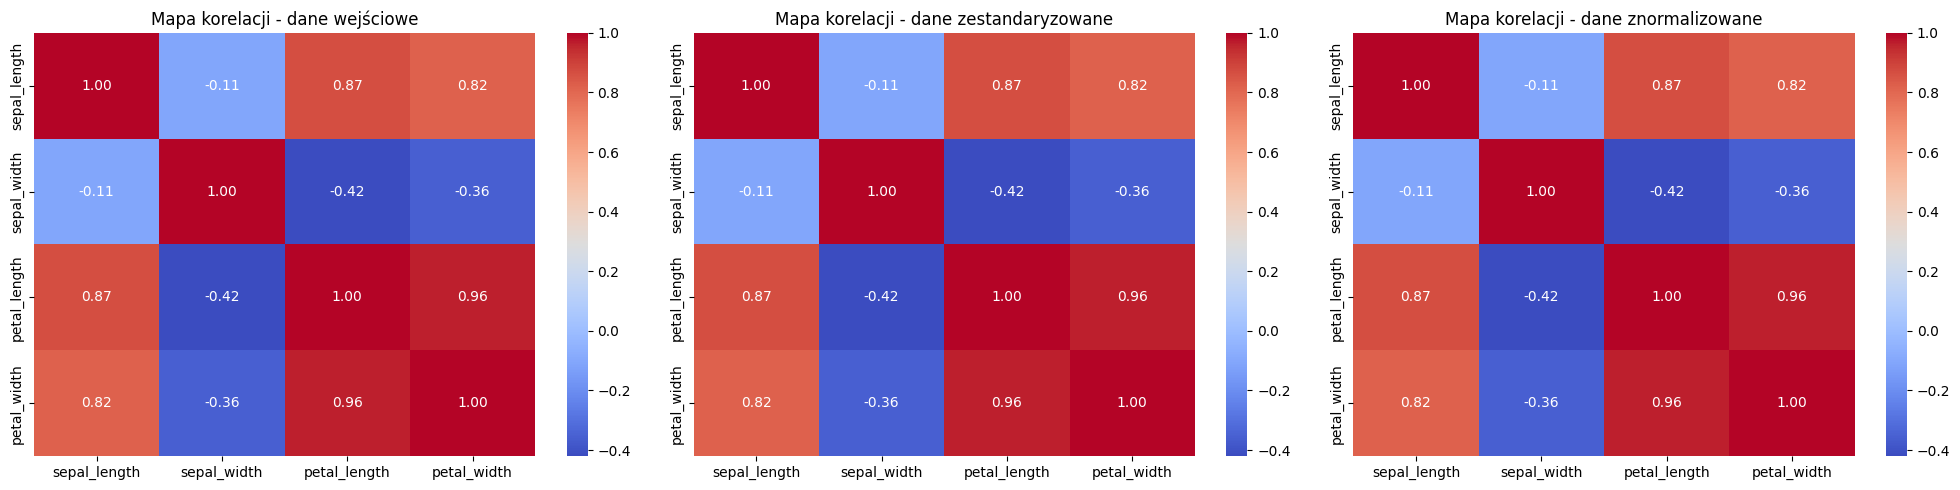

In [77]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
sns.heatmap(df_iris.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa korelacji - dane wejściowe')

plt.subplot(1, 3, 2)
sns.heatmap(df_iris_std.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa korelacji - dane zestandaryzowane')

plt.subplot(1, 3, 3)
sns.heatmap(df_iris_norm.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa korelacji - dane znormalizowane')

plt.tight_layout()
plt.show()

2.10. Dla danych oryginalnych: 
2.10.1. Zastosować algorytm hierarchiczny metody aglomeracyjnej dla odpowiedniej liczby 
grup (patrz: 2.4., 2.5.), dla 3 metod łączenia:  
 a. Warda, 
 b. pojedynczego połączenia, 
 c. całkowitego połączenia.

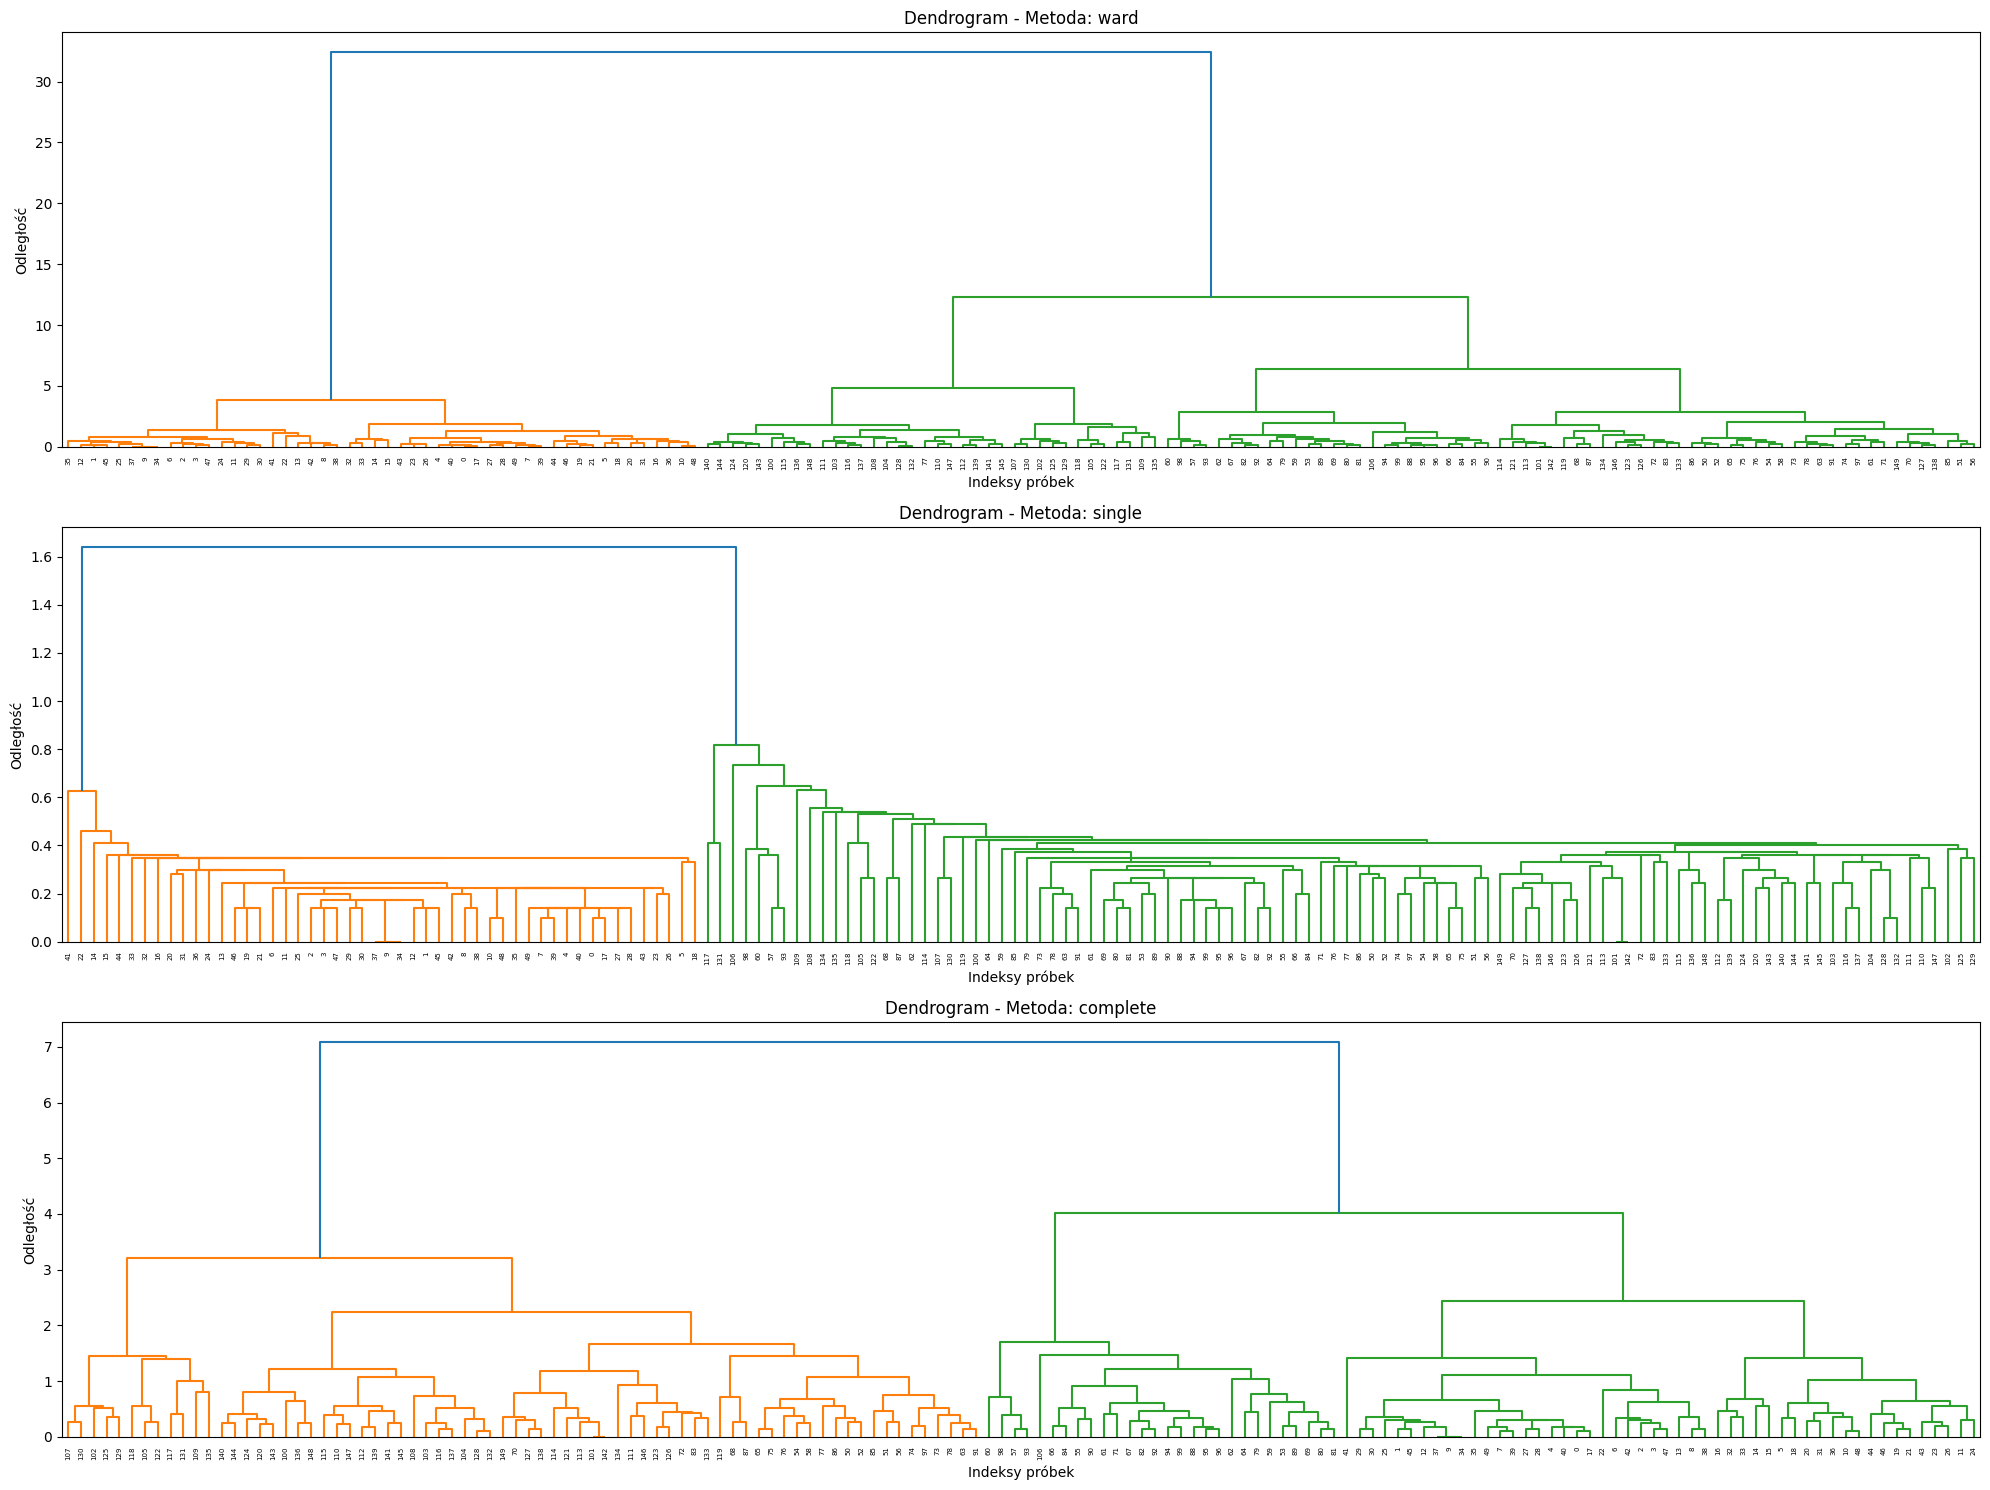

In [78]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Metody łączenia
methods = ['ward', 'single', 'complete']
plt.figure(figsize=(20, 15))

for i, method in enumerate(methods):
    # 2.10.1. Zastosowanie algorytmu hierarchicznego
    Z = linkage(df_iris, method=method)
    
    # Wykres dendrogramu
    plt.subplot(3, 1, i + 1)
    dendrogram(Z, labels=df.index, leaf_rotation=90)
    plt.title(f'Dendrogram - Metoda: {method}')
    plt.xlabel('Indeksy próbek')
    plt.ylabel('Odległość')

plt.tight_layout()
plt.show()

2.10.2. Zastosowanie algorytmu k-średnich dla odpowiedniej liczby grup (patrz: 2.4., 2.5.).

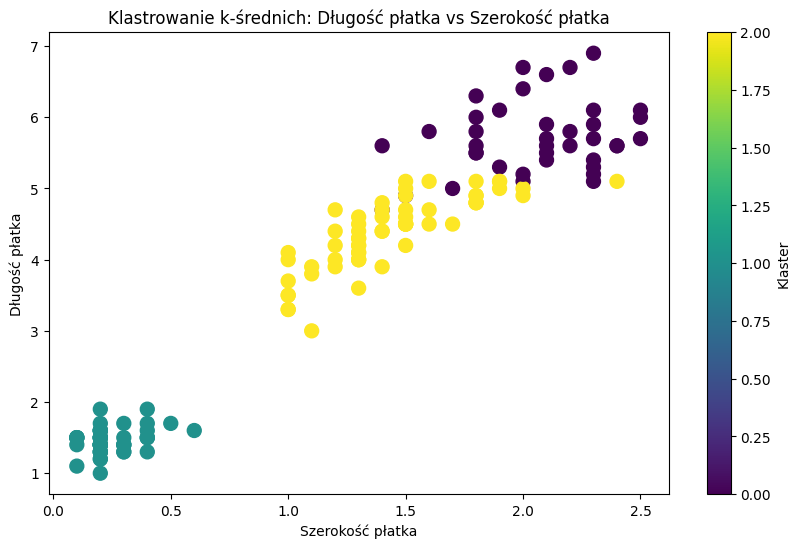

Centroidy klastrów:
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.418      1.464      0.244     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


In [79]:
from sklearn.cluster import KMeans

# 2.10.2. Zastosowanie algorytmu k-średnich dla 3 grup
kmeans = KMeans(n_clusters=3, random_state=42)  # Ustalamy 3 grupy
df['Cluster'] = kmeans.fit_predict(df_iris)  # Przypisujemy etykiety klastrów do oryginalnych danych

# Wykres punktowy długości i szerokości płatka z kolorami klastra
plt.figure(figsize=(10, 6))
plt.scatter(df['petal_width'], df['petal_length'], c=df['Cluster'], cmap='viridis', s=100)
plt.title('Klastrowanie k-średnich: Długość płatka vs Szerokość płatka')
plt.xlabel('Szerokość płatka')
plt.ylabel('Długość płatka')
plt.colorbar(label='Klaster')
plt.show()

# Wyświetlenie współrzędnych centroidów
centroids = kmeans.cluster_centers_
print("Centroidy klastrów:")
print(centroids)

2.10.3.  Jaki  jest  wynik  profilu  dla  poszczególnych  rozwiązań  uzyskanych  metodą 
aglomeracyjną, a jaki jest wynik profilu dla rozwiązań metodą k-średnich? 

In [88]:
from sklearn.cluster import AgglomerativeClustering, KMeans

agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Agglomerative_Cluster'] = agglo.fit_predict(df_iris_norm)


ValueError: could not convert string to float: 'setosa'

In [85]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df)

In [87]:
profile_agglomerative = df.groupby('Agglomerative_Cluster').mean(numeric_only=True)
print("Profil klastrów dla metody aglomeracyjnej:")
print(profile_agglomerative)

# Profil dla klastrów uzyskanych metodą k-średnich
profile_kmeans = df.groupby('KMeans_Cluster').mean(numeric_only=True)
print("\nProfil klastrów dla metody k-średnich:")
print(profile_kmeans)

Profil klastrów dla metody aglomeracyjnej:
                       sepal_length  sepal_width  petal_length  petal_width  \
Agglomerative_Cluster                                                         
0                          5.950746     2.750746      4.462687     1.450746   
1                          5.006000     3.418000      1.464000     0.244000   
2                          6.893939     3.118182      5.806061     2.133333   

                       KMeans_Cluster  
Agglomerative_Cluster                  
0                            1.432836  
1                            1.000000  
2                            0.000000  

Profil klastrów dla metody k-średnich:
                sepal_length  sepal_width  petal_length  petal_width  \
KMeans_Cluster                                                         
0                   6.703846     3.063462      5.467308     1.976923   
1                   5.006000     3.418000      1.464000     0.244000   
2                   5.783333     

2.10.4. Wykres punktowy zależności długości płatka w funkcji szerokości płatka: 
o dane różnicowane za pomocą etykiet nadanych za pomocą algorytmu hierarchicznego 
dla każdej metody łączenia. 
o dane różnicowane za pomocą etykiet nadanych za pomocą algorytmu k-średnich.

In [90]:
agglo_ward = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Agglomerative_Cluster_Ward'] = agglo_ward.fit_predict(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

# Klasteryzacja z metodą pojedynczego połączenia
agglo_single = AgglomerativeClustering(n_clusters=3, linkage='single')
df['Agglomerative_Cluster_Single'] = agglo_single.fit_predict(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

# Klasteryzacja z metodą całkowitego połączenia
agglo_complete = AgglomerativeClustering(n_clusters=3, linkage='complete')
df['Agglomerative_Cluster_Complete'] = agglo_complete.fit_predict(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])